# Transformer (COMING SOON)

In this section, we will generate forecasts of EEG activity using a Transformer-based model. The VARIMA, DMD, and TCN models primarly focus on modeling short-term temporal correlations within a system and struggle to capture the global dynamics present within long-term time windows. Transformers, on the other hand, excel at modeling the long-range dependencies between samples of a sequence—making them a promising approach to characterize and forecast the multi-scale temporal structures present in neural activity.    

## Background

Introduced in the seminal paper "Attention Is All You Need" by Vaswani et al. (2017), the Transformer architecture shifted the deep learning paradigm. It demonstrated that attention mechanisms alone are sufficient for complex sequence modeling and transduction (converting an input sequence into an output sequence), completely dispensing with the recurrent constraints of traditional models like RNNs or LSTMs.

By processing entire sequences simultaneously rather than step-by-step, Transformers unlocked massive parallelism, enabling the training of massive models on vast datasets. Today, this architecture powers cutting-edge Large Language Models (LLMs), effectively capturing complex semantic relationships between words regardless of their distance within a text.

### Attention

At the heart of the Transformer is the attention mechanism, which maps dependencies between elements in a sequence. To understand how it works under the hood, let's trace an input sequence through the model:
- Tokenization: Raw text is broken down into smaller pieces (words, sub-words, or characters) called tokens. Let $\mathbf{S} = \{s_1, s_2, \dots, s_L\}$ represent a sequence of tokens of length $L$.
- Embedding: Because deep learning models cannot process raw text, we map each discrete token $s_i$ into a continuous, high-dimensional vector space. This yields an input embedding matrix $\mathbf{X} \in \mathbb{R}^{L \times d_{\text{model}}}$, where each row captures the base semantic meaning of a token, and $d_{\text{model}}$ represents the dimension of the embedding space.

While static embeddings capture generalized semantic meaning, they ignore context. For example, the word "bad" has a negative valence in "The food has gone bad", but a positive valence in "He was one bad basketball player—no one could stop him." The attention mechanism solves this by dynamically updating token representations based on their surrounding context.

#### Queries, Keys, and Values

It is helpful to think of attention like a database retrieval system. You submit a Query ($\mathbf{Q}$), match it against a set of Keys ($\mathbf{K}$) corresponding to entries in the database, and retrieve the best-matching Values ($\mathbf{V}$).

To generate these, we project our embedding matrix $\mathbf{X}$ using three distinct, learned linear weight matrices:

$$\mathbf{Q} = \mathbf{X}\mathbf{W}^Q, \quad \mathbf{K} = \mathbf{X}\mathbf{W}^K, \quad \mathbf{V} = \mathbf{X}\mathbf{W}^V$$

where $\mathbf{W}^Q, \mathbf{W}^K \in \mathbb{R}^{d_{\text{model}} \times d_k}$ and $\mathbf{W}^V \in \mathbb{R}^{d_{\text{model}} \times d_v}$.

#### Scaled Dot-Product Attention

We compute the dot-product $\mathbf{QK}^T$ to determine the similarity between queries and keys. However, unscaled dot-products can grow excessively large in higher dimensions. This pushes the softmax function into regions with dangerously small gradients (saturation), which halts learning. Furthermore, unscaled dot-products scale linearly, potentially leading to an unbalanced weighted average where dominant tokens obliterate the original semantic nuances.

To stabilize gradients and filter out irrelevant keys, we scale the dot-product by $\frac{1}{\sqrt{d_k}}$ before applying the softmax function. Multiplying this result by the value matrix $\mathbf{V}$ yields the Scaled Dot-Product Attention formula:

$$\mathbf{A}(\mathbf{Q, K, V}) = \text{softmax}\left(\frac{\mathbf{QK}^T}{\sqrt{d_k}}\right)\mathbf{V} \tag{1}$$

where $\mathbf{A} \in \mathbb{R}^{L \times d_v}$ represents the context-aware representations of our tokens.

#### Positional Encoding

By default, the attention formula is entirely invariant to sequence order—meaning "the cat ate the fish" and "the fish ate the cat" would produce identical attention weights. To preserve word order, we add a Positional Encoding (PE) matrix directly to our initial embeddings.

The original paper uses deterministic, alternating sine and cosine waves of different frequencies to encode these positions:

$$
\begin{align*}
PE_{pos, 2i} = \text{sin}(\frac{pos}{1000^{\frac{2i}{d_{model}}}}) \\
\\
PE_{pos, 2i+1} = \text{cos}(\frac{pos}{1000^{\frac{2i}{d_{model}}}})
\end{align*}
$$

### Multihead Attention

To allow the model to focus on different parts of a sequence simultaneously (e.g., tracking both grammatical structure and long-range pronouns in parallel), we use Multi-Head Attention (MHA).

Instead of performing a single attention operation, we project $\mathbf{X}$ into $h$ separate sets of $\mathbf{Q, K, V}$ matrices. For each head $i = 1, \dots, h$, we compute attention independently:

$$\text{head}_i = \mathbf{A}(\mathbf{Q}_i, \mathbf{K}_i, \mathbf{V}_i) = \text{softmax}\left(\frac{\mathbf{Q}_i \mathbf{K}_i^T}{\sqrt{d_k}}\right) \mathbf{V}_i$$

By setting $d_k = d_v = \frac{d_{\text{model}}}{h}$, we can reshape our tensors to process all $h$ heads in parallel without increasing overall computational cost. Finally, we concatenate the outputs of all heads and project them back using a learned weight matrix $\mathbf{W}^O \in \mathbb{R}^{h d_v \times d_{\text{model}}}$:

$$\text{MultiHead}(\mathbf{Q, K, V}) = \text{Concat}(\text{head}_1, \text{head}_2, \dots, \text{head}_h)\mathbf{W}^O$$

### Model Architecture

The classic Transformer relies on an Encoder-Decoder architecture, optimized for sequence-to-sequence tasks:
- Encoder: Processes the input sequence. After adding positional encodings, the data passes through stacked encoder layers utilizing self-attention (Equation 1) to deeply contextualize each token relative to all other tokens in the input.
- Decoder: Generates the target sequence. It leverages its own queries ($\mathbf{Q}_{\text{dec}}$) alongside the keys ($\mathbf{K}_{\text{enc}}$) and values ($\mathbf{V}_{\text{enc}}$) exported from the encoder (often stored in a KV cache during generation). This interaction is known as Cross-Attention:

$$\text{CrossAttention}(\mathbf{Q}_{\text{dec}}, \mathbf{K}_{\text{enc}}, \mathbf{V}_{\text{enc}}) = \text{softmax}\left(\frac{\mathbf{Q}_{\text{dec}}\mathbf{K}_{\text{enc}}^T}{\sqrt{d_k}}\right)\mathbf{V}_{\text{enc}}$$

This operation treats the encoder's outputs as a stable database. The decoder uses queries from the target sequence to look up related tokens from the input sequence, seamlessly blending information across both domains.

#### Training vs. Inference

To speed up training, the model uses Teacher Forcing, feeding the entire ground-truth target sequence into the decoder simultaneously. To prevent the model from "cheating" by looking ahead, a causal mask replaces future positions with $-\infty$ before the softmax step, zeroing out future attention weights.

During inference, the process becomes autoregressive: the model predicts the next token $\hat{s}_{L+1}$, appends it to the target sequence, and feeds the updated sequence back into the decoder to predict the subsequent token.

### From NLP to Time Series Forecasting

Adapting the Transformer from discrete language tokens to continuous-valued time series requires several modifications.

**Input representation.** In NLP, tokens are drawn from a finite vocabulary and embedded via a lookup table. Time series observations are continuous, so a learned linear projection is used instead to map each time step's values into the model dimension. For multivariate recordings like EEG, the input at each step is a vector $\mathbf{x}_t \in \mathbb{R}^m$ across $m$ channels.

**Efficient attention for long sequences.** Computing $QK^\top$ requires a dot product between every pair of time steps, producing an attention matrix of size $T \times T$. Both the computation and memory therefore scale as $\mathcal{O}(T^2)$—doubling the sequence length quadruples the cost. For short sentences this is acceptable, but for long high-frequency signals like EEG (e.g., $T = 1000$ steps at 256 Hz), the attention matrix alone contains $10^6$ entries, making full attention computationally prohibitive.

Several architectures address this:

- **FEDformer** (Zhou et al., 2022) performs attention in the frequency domain using a sparse Fourier or wavelet decomposition. By attending over spectral components rather than individual time steps, it efficiently captures the global periodicities and trends that are particularly prominent in neural oscillations.

- **PatchTST** (Nie et al., 2023) divides the input into non-overlapping patches and treats each patch as a token, dramatically shortening the effective sequence length and improving long-horizon accuracy.

- **Direct multi-step prediction head.** Rather than decoding one step at a time as in NLP, many time series Transformers attach a linear projection head to the encoder output that maps the full context representation to all $H$ future steps simultaneously, sidestepping the exposure bias inherent in autoregressive decoding.

- **Informer** (Zhou et al., 2021) introduces *ProbSparse* attention. The key observation is that in practice, each query's attention distribution is highly uneven: a small number of keys dominate and the rest receive near-zero weight. Informer identifies the most *informative* queries—those with the most peaked distributions—by scoring each query $q_i$ against a random sample of $\ln T$ keys:

$$\bar{M}(q_i, K) = \max_{j} \left\{\frac{q_i k_j^\top}{\sqrt{d_k}}\right\} - \frac{1}{T}\sum_{j=1}^{T} \frac{q_i k_j^\top}{\sqrt{d_k}}$$

  A large $\bar{M}$ means the query's attention is concentrated (informative); a small value means it is nearly uniform (uninformative). Only the top-$u = c \ln T$ queries by this score are selected to participate in full attention, while all remaining queries default to the mean of $V$:

$$\text{ProbSparseAttn}(\bar{Q}, K, V) = \text{softmax}\!\left(\frac{\bar{Q}K^\top}{\sqrt{d_k}}\right)V$$

  where $\bar{Q} \in \mathbb{R}^{u \times d_k}$ is the selected query subset. This reduces complexity to $\mathcal{O}(T \log T)$ in both time and memory.

In this tutorial, we implement the **Informer**, whose ProbSparse attention mechanism makes it well-suited to the long, high-frequency nature of EEG recordings.

## Implementing

With the theoretical foundation in place, we can now see the Informer in action. The sections below build the model from the ground up: first the attention mechanisms, then the multi-head wrapper and positional encoding, then the encoder layer with its distilling operation, and finally the full `TimeSeriesTransformer` that ties everything together.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import math
from tqdm import trange
import matplotlib.pyplot as plt

First, lets load the dataset:

In [2]:
# load single subject from Gu et al., 2024 SSVEP experiment
# Note, data has been downsampled to 250 Hz
data = np.load('../dataset/Data/data_s1_64_down.npy')

In [3]:
# block x stimulation frequency x time x channels x conditions (i.e., modulation depths; low and high luminance ratios)
# stimulation frequencies are from 1-60 in increments of 1 Hz
nBlocks, nFreqs, nTime, nChans, nCons = data.shape

# block x stim freqs x time x channels
con_idx = 1
X = data[:, :, :, :, con_idx]

# collapse over stimulation frequencies to increase amount of data
X = X.reshape(-1, *X.shape[2:])

# transpose to make block x channels x time
X = np.swapaxes(X, 1, 2)

# SSVEPs are typically localized over the P-PO-O electrodes 
ssvep_chan_names = ['Pz', 'PO5', 'PO3', 'POz', 'PO4', 'PO6', 'O1', 'Oz', 'O2']
ssvep_chans_idx = [48,54,55,56,57,58,61,62,63]

ssvep_chans_dict = dict(zip(ssvep_chan_names, ssvep_chans_idx))

In [4]:
# construct time vector. Stimulation time is 5s, and epochs included 0.14s post stimulus offset
Fs = 250.
t = np.arange(0, 5.14, 1/Fs) * 1000

In [5]:
# define custom dataloader 
class customDataSet(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        # sample dataset
        X = self.data[idx, :]
        return X

### Attention Mechanisms

We implement two attention functions side by side. `scaled_dot_product_attention` is the standard $\mathcal{O}(T^2)$ formulation and serves as a reference. `ProbSparseAttention` is the Informer's replacement: it scores every query cheaply using a sample of keys, selects only the most informative ones, and runs full attention exclusively on that subset — reducing complexity to $\mathcal{O}(T \log T)$.

In [6]:
# ── Traditional Scaled Dot-Product Attention (reference) ─────────────────────
# Computes full O(T²) attention — every query attends to every key.
def scaled_dot_product_attention(
    Q: torch.Tensor, K: torch.Tensor, V: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> torch.Tensor:
    d_k: int = Q.size(-1)
    # Build the T×T pairwise similarity matrix
    scores: torch.Tensor = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    # Normalize to a probability distribution and retrieve values
    attn: torch.Tensor = F.softmax(scores, dim=-1)
    return torch.matmul(attn, V)


# ── ProbSparse Attention (Informer) ──────────────────────────────────────────
# Only the top-u most informative queries run full attention; the rest default
# to mean(V), reducing complexity to O(T log T).
class ProbSparseAttention(nn.Module):

    def __init__(self, factor: int = 5, dropout: float = 0.1):
        super().__init__()
        self.factor: int = factor   # sampling constant c; selects u = c·ln(T) queries
        self.dropout = nn.Dropout(dropout)

    def _sparsity_score(
        self, Q: torch.Tensor, K: torch.Tensor, sample_k: int
    ) -> torch.Tensor:
        """Score each query: large score → peaked distribution → informative."""
        L_K: int = K.size(2)
        # Sample a random subset of keys to approximate the score cheaply
        idx: torch.Tensor = torch.randint(L_K, (sample_k,), device=Q.device)
        K_sample: torch.Tensor = K[:, :, idx, :]                            # (B, H, sample_k, D)
        # Dot products between every query and the sampled keys
        QK: torch.Tensor = torch.matmul(Q, K_sample.transpose(-2, -1))      # (B, H, L_Q, sample_k)
        # M = max − mean: high when attention is concentrated on a few keys
        return QK.max(dim=-1).values - QK.mean(dim=-1)                      # (B, H, L_Q)

    def forward(
        self, Q: torch.Tensor, K: torch.Tensor, V: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        B, H, L_Q, D = Q.shape
        L_K: int = K.size(2)
        scale: float = D ** -0.5

        # Select u = factor·ln(L_K) top queries, capped at L_Q
        u: int = min(self.factor * math.ceil(math.log(L_K)), L_Q)
        M: torch.Tensor = self._sparsity_score(Q, K, sample_k=u)
        top_idx: torch.Tensor = M.topk(u, dim=-1).indices                   # (B, H, u)

        # Gather only the u selected queries for full attention
        Q_sparse: torch.Tensor = Q.gather(
            dim=2, index=top_idx.unsqueeze(-1).expand(-1, -1, -1, D)
        )                                                                    # (B, H, u, D)

        # Full attention over selected queries only — O(u·L_K) vs O(L_Q·L_K)
        scores: torch.Tensor = torch.matmul(Q_sparse, K.transpose(-2, -1)) * scale
        if mask is not None:
            scores = scores.masked_fill(mask[:, :, :u, :L_K] == 0, float('-inf'))
        attn: torch.Tensor = self.dropout(F.softmax(scores, dim=-1))
        attended: torch.Tensor = torch.matmul(attn, V)                      # (B, H, u, D)

        # Non-selected queries default to the uniform-attention baseline: mean(V)
        out: torch.Tensor = V.mean(dim=2, keepdim=True).expand(B, H, L_Q, D).clone()
        out.scatter_(dim=2, index=top_idx.unsqueeze(-1).expand(-1, -1, -1, D), src=attended)
        return out, attn

### Multi-Head Attention and Positional Encoding

`MultiHeadAttention` wraps `ProbSparseAttention` in the standard multi-head projection scheme: it linearly projects the input into $h$ separate Q, K, V subspaces, runs ProbSparse attention in each head in parallel, then merges and re-projects the results. `PositionalEncoding` adds a fixed sinusoidal signal to each embedded time step so the model knows the order of the sequence.

In [7]:
class MultiHeadAttention(nn.Module):
    """Runs ProbSparse attention across h independent learned subspaces."""

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads: int = n_heads
        self.d_k: int = d_model // n_heads   # dimension per head

        # Separate weight matrices produce Q, K, V from the same input
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model)    # merges all heads back to d_model
        self.attn = ProbSparseAttention(dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """Reshape (B, T, d_model) → (B, n_heads, T, d_k) for parallel head computation."""
        B, T, _ = x.shape
        return x.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

    def forward(
        self, Q: torch.Tensor, K: torch.Tensor, V: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        # Project input into Q, K, V and split across heads
        q: torch.Tensor = self._split_heads(self.W_Q(Q))
        k: torch.Tensor = self._split_heads(self.W_K(K))
        v: torch.Tensor = self._split_heads(self.W_V(V))
        # Attention runs simultaneously across all heads
        ctx, _ = self.attn(q, k, v, mask=mask)
        # Merge heads and project back to d_model
        ctx = ctx.transpose(1, 2).contiguous().view(Q.size(0), Q.size(1), -1)
        return self.dropout(self.W_O(ctx))


class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding (Vaswani et al., 2017)."""

    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        # Pre-compute the encoding table: alternating sin/cos across model dimensions
        pe: torch.Tensor = torch.zeros(max_len, d_model)
        pos: torch.Tensor = torch.arange(max_len, dtype=torch.float).unsqueeze(1)
        div: torch.Tensor = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) * -(math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))    # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Add the positional signal to each embedded time step
        return self.dropout(x + self.pe[:, :x.size(1)])

### Encoder Layer

Each `EncoderLayer` combines three operations. First, ProbSparse multi-head self-attention with a residual connection lets each time step gather context from informative positions across the sequence. Second, a position-wise feed-forward network applies a non-linear transformation independently at each step. Third, a **distilling** operation — a 1-D convolution followed by max-pooling — halves the sequence length, progressively compressing the temporal context as it passes through successive encoder layers. This cascading reduction is a key feature of the Informer: it trades some temporal resolution for dramatically lower memory and compute at deeper layers.

In [8]:
class EncoderLayer(nn.Module):
    """Informer encoder layer: ProbSparse self-attention + feed-forward + distilling."""

    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)

        # Position-wise feed-forward: expands to d_ff then projects back
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        # Layer norms stabilize training after each sub-layer
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        # Distilling: ELU-activated conv + max-pool halves the sequence length
        self.distil = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
        )

    def forward(
        self, x: torch.Tensor, mask: torch.Tensor | None = None
    ) -> torch.Tensor:
        # Self-attention sub-layer with residual connection
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, mask)))
        # Feed-forward sub-layer with residual connection
        x = self.norm2(x + self.ff(x))
        # Distilling: (B, T, d_model) → (B, T//2, d_model)
        x = self.distil(x.transpose(1, 2)).transpose(1, 2)
        return x

### TimeSeriesTransformer

`TimeSeriesTransformer` assembles the full model. A linear input projection maps the raw EEG channel values at each time step into the model's embedding space, after which positional encodings are added. The signal then passes through the stack of encoder layers, each halving the sequence length via distilling. Finally, a global average pool reduces the compressed sequence to a single context vector, which a linear output head maps directly to all `pred_len` forecast steps across all channels — the direct multi-step prediction strategy described in the Background section.

In [9]:
class TimeSeriesTransformer(nn.Module):
    """
    Informer-based Transformer for multivariate EEG forecasting.

    Args:
        n_channels:   Number of EEG channels (input and output features).
        d_model:      Embedding dimension throughout the model.
        n_heads:      Number of parallel attention heads.
        n_enc_layers: Encoder depth; each layer halves the sequence length.
        d_ff:         Inner dimension of the feed-forward sub-layers.
        pred_len:     Number of future time steps to forecast.
        dropout:      Dropout probability applied throughout.
    """

    def __init__(
        self,
        n_channels: int,
        d_model: int = 64,
        n_heads: int = 4,
        n_enc_layers: int = 2,
        d_ff: int = 256,
        pred_len: int = 32,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.pred_len: int = pred_len
        self.n_channels: int = n_channels

        # Project raw channel values into the model's embedding space
        self.input_proj = nn.Linear(n_channels, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)

        # Stack of encoder layers; sequence length shrinks by 2× per layer
        self.encoder = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_enc_layers)
        ])

        # Direct multi-step head: context vector → all pred_len steps × channels
        self.output_proj = nn.Linear(d_model, pred_len * n_channels)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Embed and encode the input sequence through all encoder layers."""
        z: torch.Tensor = self.pos_enc(self.input_proj(x))
        for layer in self.encoder:
            z = layer(z)
        return z                                            # (B, T', d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, T, C) — input EEG window.
        Returns:
            (B, pred_len, C) — forecasted values.
        """
        z: torch.Tensor = self.encode(x)                   # (B, T', d_model)
        # Global average pool collapses the compressed sequence to one context vector
        z_ctx: torch.Tensor = z.mean(dim=1)                # (B, d_model)
        # Project to all forecast steps simultaneously and reshape
        out: torch.Tensor = self.output_proj(z_ctx)        # (B, pred_len * n_channels)
        return out.view(x.size(0), self.pred_len, self.n_channels)

As we did in the previous TCN tutorial, lets split the data into a training, validation and test set. Then normalize the data and set training parameters:

In [10]:
nTrials = X.shape[0]
nTestTrials = math.ceil(nTrials*0.2) # 20% test
shuffIdx = np.random.permutation(nTrials)

X_test = X[shuffIdx[-nTestTrials:], :]
X_train_val = X[shuffIdx[:-nTestTrials], :]

nValidTrials = math.ceil(X_train_val.shape[0] * 0.2) # 20% validation
X_val = X_train_val[-nValidTrials:, :]
X_train = X[:-nValidTrials, :]

In [11]:
X_train_mu, X_train_sd = X_train.mean(), X_train.std()

X_train = (X_train - X_train_mu) / X_train_sd
X_val = (X_val - X_train_mu) / X_train_sd
X_test = (X_test - X_train_mu) / X_train_sd

In [12]:
X_train = torch.Tensor(X_train).to(torch.float32)
X_val = torch.Tensor(X_val).to(torch.float32)
X_test = torch.Tensor(X_test).to(torch.float32)

In [13]:
train_dataset = customDataSet(X_train)
val_dataset = customDataSet(X_val)
test_dataset = customDataSet(X_test)

In [14]:
BATCH_SIZE = 64
LEARN_RATE = 1e-3
N_EPOCHS = 300
HORIZON_MS = 1000
HORIZON = abs(t-HORIZON_MS).argmin().item() + 1 # Forecast last 1000 ms
SEQ_LENGTH = nTime - HORIZON
UPDATE_FREQ = 50

In [15]:
trainDL = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valDL = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
testDL = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [16]:
device = torch.device('cuda')

## Model Initialization and Training

With the data prepared, we can instantiate the `TimeSeriesTransformer`. Note that, unlike the TCN's channels-first convention, the Informer's input projection expects channels-last tensors of shape `(B, T, C)`, so we transpose batches accordingly before feeding them through the model.

In [17]:
# instantiate the Informer-based TimeSeriesTransformer
model = TimeSeriesTransformer(
    n_channels=nChans,    # number of EEG channels (input and output dimension)
    d_model=128,          # embedding dimension carried through the encoder
    n_heads=8,            # number of parallel ProbSparse attention heads
    n_enc_layers=3,       # encoder depth; each layer halves the sequence length via distilling
    d_ff=256,             # inner dimension of the position-wise feed-forward sub-layers
    pred_len=HORIZON,     # forecast horizon, matches the TCN tutorial's horizon
    dropout=0.1
).to(device)

In [18]:
optimizer = optim.NAdam(model.parameters(), lr=LEARN_RATE)
criterion = nn.MSELoss()

In [19]:
# Training loop
train_loss: list[float] = []
val_loss: list[float] = []
for iEpoch in trange(N_EPOCHS):
    model.train()
    epoch_train_loss = 0.0
    for train_batch in trainDL:
        # batches are (B, C, T); split chronologically into input/target windows
        input_sequence = train_batch[:, :, :-HORIZON].to(device)
        target_sequence = train_batch[:, :, -HORIZON:].to(device)

        # Informer expects channels-last (B, T, C) input
        batch_predictions = model(input_sequence.transpose(1, 2))
        # bring predictions back to (B, C, pred_len) to match target_sequence
        batch_predictions = batch_predictions.transpose(1, 2)
        batch_loss = criterion(batch_predictions, target_sequence)

        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()

        epoch_train_loss += batch_loss.item()

    train_loss.append(epoch_train_loss / len(trainDL))

    # Validation
    if (iEpoch + 1) % UPDATE_FREQ == 0:

        model.eval()
        epoch_val_loss = 0.0

        with torch.no_grad():
            for val_batch in valDL:
                input_sequence = val_batch[:, :, :-HORIZON].to(device)
                target_sequence = val_batch[:, :, -HORIZON:].to(device)

                batch_predictions = model(input_sequence.transpose(1, 2)).transpose(1, 2)
                batch_loss = criterion(batch_predictions, target_sequence)

                epoch_val_loss += batch_loss.item()

            val_loss.append(epoch_val_loss / len(valDL))

        print(f"Epoch [{iEpoch + 1}/{N_EPOCHS}] | Train Loss: {epoch_train_loss/len(trainDL):.3e} | Val Loss: {epoch_val_loss/len(valDL):.3e}")

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 1/300 [00:00<03:13,  1.55it/s]

  1%|          | 2/300 [00:00<02:06,  2.36it/s]

  1%|          | 3/300 [00:01<01:45,  2.83it/s]

  1%|▏         | 4/300 [00:01<01:34,  3.13it/s]

...

 99%|█████████▉| 298/300 [01:19<00:00,  3.79it/s]

100%|█████████▉| 299/300 [01:20<00:00,  3.74it/s]

100%|██████████| 300/300 [01:20<00:00,  3.64it/s]

100%|██████████| 300/300 [01:20<00:00,  3.74it/s]

Epoch [300/300] | Train Loss: 2.674e-01 | Val Loss: 3.636e-01


Lets take a look at the training results and how well the model performs on the test data set

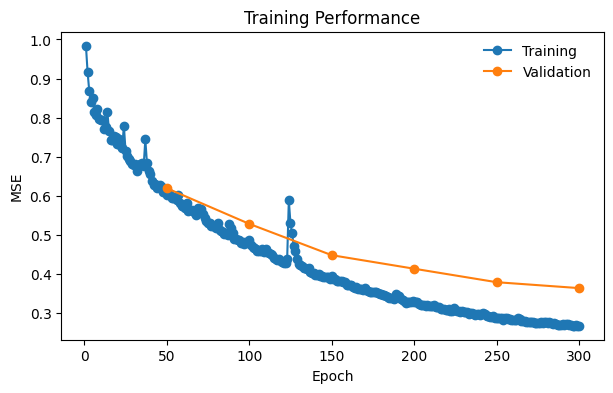

In [20]:
plt.figure(figsize=(7,4))
plt.plot(np.arange(N_EPOCHS)+1, train_loss, marker='o', label='Training')
plt.plot(
    [x for x in np.arange(N_EPOCHS) + 1 if not x % UPDATE_FREQ],
    val_loss,
    marker='o',
    label='Validation'
)
plt.title('Training Performance')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend(frameon=False)
plt.show()

In [21]:
model.eval()
with torch.no_grad():
    input_sequence = X_test[:, :, :-HORIZON].to(device)
    target_sequence = X_test[:, :, -HORIZON:].to(device)

    predictions = model(input_sequence.transpose(1, 2)).transpose(1, 2)

    # unormalize both predictions and test
    target_denorm = ((target_sequence * X_train_sd) + X_train_mu).cpu().numpy()
    predictions = ((predictions * X_train_sd) + X_train_mu).cpu().numpy()

    residuals = target_denorm - predictions
    test_rmse = np.sqrt((residuals**2).mean())

print(f'Test RMSE: {test_rmse:0.3e}')

Test RMSE: 6.485e+00


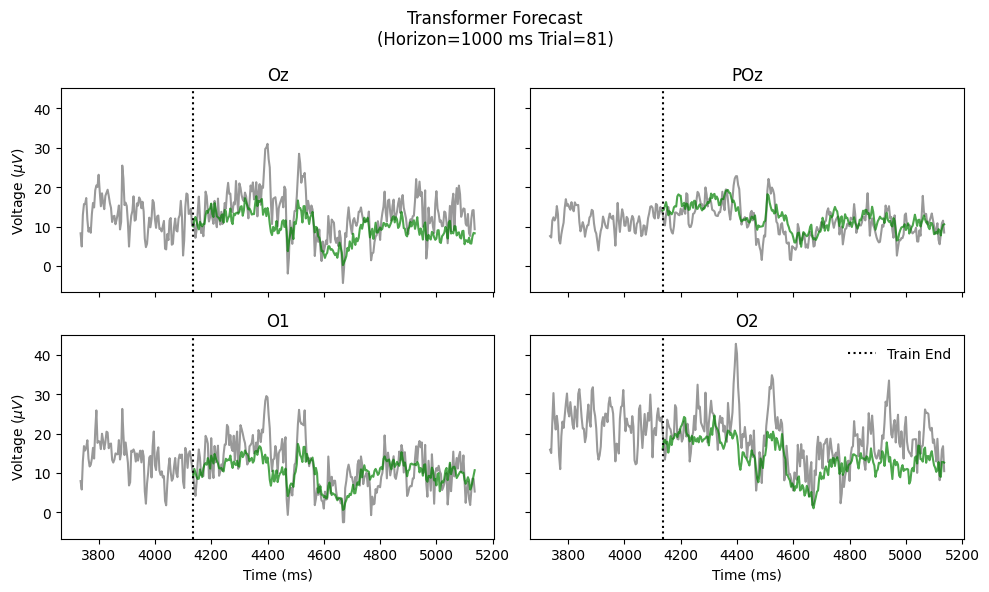

In [22]:
# Plot single trial performance
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 6), dpi=100, sharex=True, sharey=True)
trial_idx = 80
time_plot_buffer = 100 # make visualization easier
axs = axs.ravel()

X_test_denorm = ((X_test * X_train_sd) + X_train_mu).cpu().numpy()

for i, c in enumerate(['Oz', 'POz', 'O1', 'O2']):

    axs[i].plot(t[-(HORIZON+time_plot_buffer):], X_test_denorm[trial_idx, ssvep_chans_dict[c], -(HORIZON+time_plot_buffer):], 
                color='k', alpha=0.4)
    axs[i].plot(t[-HORIZON:], predictions[trial_idx, ssvep_chans_dict[c], :], color='g', alpha=0.7)
    axs[i].set_title(c)
    axs[i].axvline(t[-HORIZON], color='black', linestyle=':', label='Train End')

    if i > 1:
        axs[i].set_xlabel('Time (ms)')

    if i in [0, 2]:
        axs[i].set_ylabel(r'Voltage ($\mu V$)')

    if i==3:
        axs[i].legend(frameon=False)

plt.suptitle(f'Transformer Forecast\n(Horizon={HORIZON_MS} ms Trial={trial_idx+1})')
plt.tight_layout()
plt.show()

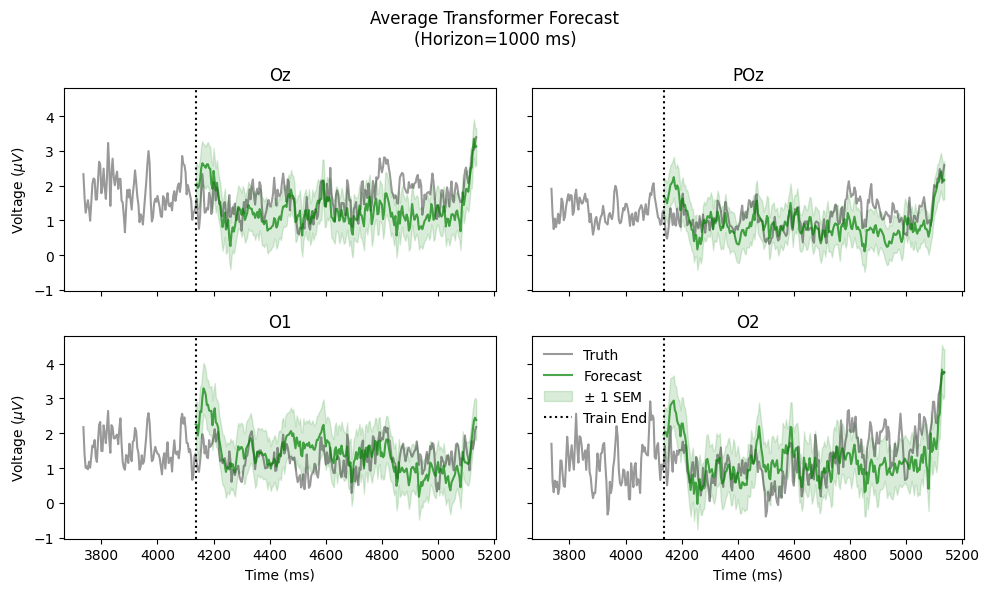

In [23]:
# Plot forecasting performance averaged across trials
average_preds = predictions.mean(axis=0)
average_truth = X_test_denorm.mean(axis=0)

preds_sem = predictions.std(axis=0) / np.sqrt(predictions.shape[0])

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 6), dpi=100, sharex=True, sharey=True)
time_plot_buffer = 100 # make visualization easier
axs = axs.ravel()
for i, c in enumerate(['Oz', 'POz', 'O1', 'O2']):

    axs[i].plot(t[-(HORIZON+time_plot_buffer):], average_truth[ssvep_chans_dict[c], -(HORIZON+time_plot_buffer):], 
                color='k', alpha=0.4, label='Truth')
    axs[i].plot(t[-HORIZON:], average_preds[ssvep_chans_dict[c], :], color='g', alpha=0.7, label='Forecast')
    axs[i].fill_between(
        t[-HORIZON:],
        average_preds[ssvep_chans_dict[c], :]-preds_sem[ssvep_chans_dict[c], :],
        average_preds[ssvep_chans_dict[c], :]+preds_sem[ssvep_chans_dict[c], :],
        color='g',
        alpha=0.15,
        label=r'$\pm \ 1 \text{ SEM}$'
    )
    axs[i].set_title(c)
    axs[i].axvline(t[-HORIZON], color='black', linestyle=':', label='Train End')

    if i > 1:
        axs[i].set_xlabel('Time (ms)')

    if i in [0, 2]:
        axs[i].set_ylabel(r'Voltage ($\mu V$)')

    if i==3:
        axs[i].legend(frameon=False)

plt.suptitle(f'Average Transformer Forecast\n(Horizon={HORIZON_MS} ms)')
plt.tight_layout()
plt.show()